📂 Por favor, sube el archivo 'Datos para entrenar el modelo de machine learning.xlsx'


Saving Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx to Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx
Saving Datos para entrenar el modelo de machine learning.xlsx to Datos para entrenar el modelo de machine learning.xlsx
✅ Datos de 200°C procesados: 30 puntos detectados.

🚀 RESULTADOS DEL MODELO (200°C)
k1 (Degradación Proteína): 0.008725 min⁻¹
k2 (Formación Melanoidinas): -0.148018 min⁻¹
P0 (Concentración Inicial): 15.2826
M_offset (Base inicial M): 17.0929


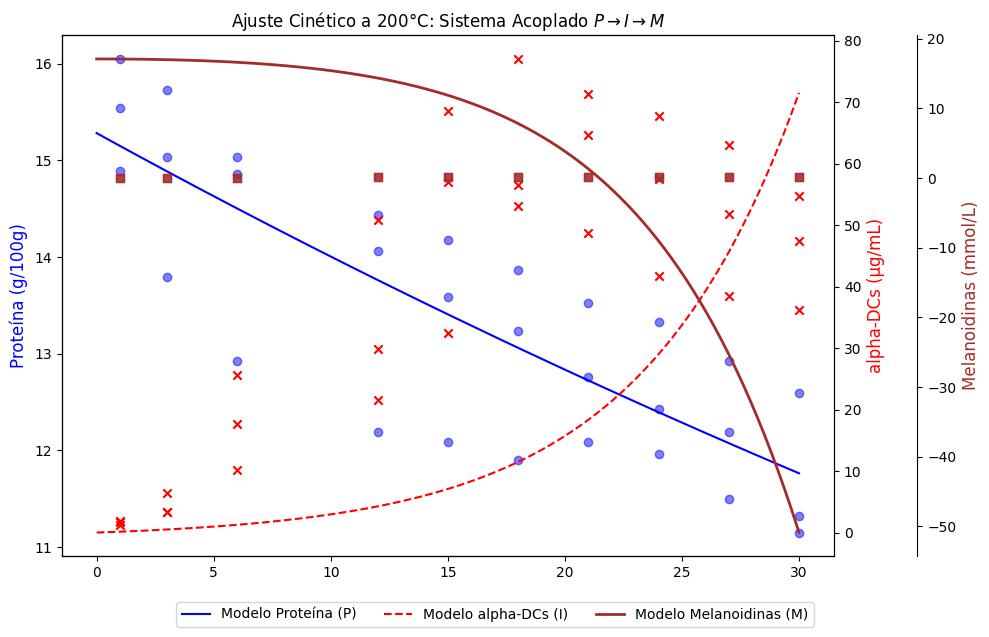

In [14]:
# =================================================================
# MODELO CINÉTICO DE MAILLARD: SOLUCIÓN ANALÍTICA (P -> I -> M)
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from google.colab import files

# 1. CARGA DEL ARCHIVO
print("📂 Por favor, sube el archivo 'Datos para entrenar el modelo de machine learning.xlsx'")
uploaded = files.upload()

file_name = None
for f_uploaded in uploaded.keys():
    if 'machine learning' in f_uploaded.lower():
        file_name = f_uploaded
        break

if file_name is None:
    raise FileNotFoundError("No se encontró el archivo de Excel con el nombre esperado.")

# 2. PROCESAMIENTO DE DATOS (200°C)
# Según la estructura: Col 1: Tiempo, Col 2: alpha-DCs, Col 4: Melanoidinas, Col 6: Proteína
df_raw = pd.read_excel(file_name, skiprows=4)

try:
    tiempos = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
    dcs_obs = pd.to_numeric(df_raw.iloc[:, 2], errors='coerce')
    melanoidinas_obs = pd.to_numeric(df_raw.iloc[:, 4], errors='coerce')
    proteina_obs = pd.to_numeric(df_raw.iloc[:, 6], errors='coerce')

    mask = tiempos.notna() & dcs_obs.notna() & melanoidinas_obs.notna() & proteina_obs.notna()

    t_data = tiempos[mask].values
    i_data = dcs_obs[mask].values
    m_data = melanoidinas_obs[mask].values
    p_data = proteina_obs[mask].values

    print(f"✅ Datos de 200°C procesados: {len(t_data)} puntos detectados.")
except Exception as e:
    print(f"❌ Error al procesar columnas: {e}")

# 3. DEFINICIÓN DE ECUACIONES (SOLUCIÓN ANALÍTICA)
def modelo_P(t, k1, P0):
    """Ecuación para la degradación de Proteína"""
    return P0 * np.exp(-k1 * t)

def modelo_I(t, k1, k2, P0):
    """Ecuación para el intermediario alpha-DCs"""
    return (k1 * P0 / (k2 - k1 + 1e-9)) * (np.exp(-k1 * t) - np.exp(-k2 * t))

def modelo_M(t, k1, k2, P0, M_offset):
    """Ecuación para la formación de Melanoidinas"""
    term = (k1 * np.exp(-k2 * t) - k2 * np.exp(-k1 * t)) / (k2 - k1 + 1e-9)
    return M_offset + P0 * (1 + term)

# 4. AJUSTE DE PARÁMETROS (ESTRATEGIA EN CASCADA)
try:
    # Paso A: Ajustar Proteína para obtener k1 y P0
    popt_p, _ = curve_fit(modelo_P, t_data, p_data, p0=[0.05, p_data[0]])
    k1_fit, P0_fit = popt_p

    # Paso B: Ajustar alpha-DCs para obtener k2 (usando k1 y P0 previos)
    def fit_I(t, k2): return modelo_I(t, k1_fit, k2, P0_fit)
    popt_i, _ = curve_fit(fit_I, t_data, i_data, p0=[0.1])
    k2_fit = popt_i[0]

    # Paso C: Ajustar Melanoidinas para el offset
    def fit_M(t, M_off): return modelo_M(t, k1_fit, k2_fit, P0_fit, M_off)
    popt_m, _ = curve_fit(fit_M, t_data, m_data, p0=[m_data[0]])
    M_off_fit = popt_m[0]

    print("\n" + "="*40)
    print("🚀 RESULTADOS DEL MODELO (200°C)")
    print("="*40)
    print(f"k1 (Degradación Proteína): {k1_fit:.6f} min⁻¹")
    print(f"k2 (Formación Melanoidinas): {k2_fit:.6f} min⁻¹")
    print(f"P0 (Concentración Inicial): {P0_fit:.4f}")
    print(f"M_offset (Base inicial M): {M_off_fit:.4f}")
    print("="*40)

except Exception as e:
    print(f"⚠️ Error en el ajuste numérico: {e}")

# 5. VISUALIZACIÓN DE RESULTADOS
t_plot = np.linspace(0, max(t_data), 100)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Proteína
ax1.plot(t_plot, modelo_P(t_plot, k1_fit, P0_fit), 'b-', label='Modelo Proteína (P)')
ax1.scatter(t_data, p_data, color='blue', alpha=0.5)
ax1.set_ylabel('Proteína (g/100g)', color='blue', fontsize=12)

# alpha-DCs
ax2 = ax1.twinx()
ax2.plot(t_plot, modelo_I(t_plot, k1_fit, k2_fit, P0_fit), 'r--', label='Modelo alpha-DCs (I)')
ax2.scatter(t_data, i_data, color='red', marker='x')
ax2.set_ylabel('alpha-DCs (μg/mL)', color='red', fontsize=12)

# Melanoidinas
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(t_plot, modelo_M(t_plot, k1_fit, k2_fit, P0_fit, M_off_fit), 'brown', lw=2, label='Modelo Melanoidinas (M)')
ax3.scatter(t_data, m_data, color='brown', marker='s', alpha=0.5)
ax3.set_ylabel('Melanoidinas (mmol/L)', color='brown', fontsize=12)

plt.title('Ajuste Cinético a 200°C: Sistema Acoplado $P \\rightarrow I \\rightarrow M$')
fig.tight_layout()
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3)
plt.show()

📂 Por favor, sube el archivo 'Datos para entrenar el modelo de machine learning.xlsx'


Saving Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx to Datos para entrenar el modelo constantes de velocidad para el modelo cinético (1).xlsx
Saving Datos para entrenar el modelo de machine learning.xlsx to Datos para entrenar el modelo de machine learning (1).xlsx
✅ Datos de 220°C cargados: 30 puntos.

📊 RESULTADOS CINÉTICOS A 220°C
k1 (Degradación Proteína):   0.010318 min⁻¹
k2 (Formación Melanoidinas): -0.130456 min⁻¹
P0 (Concentración Inicial):  15.3076
M_offset (Base inicial M): 13.6864


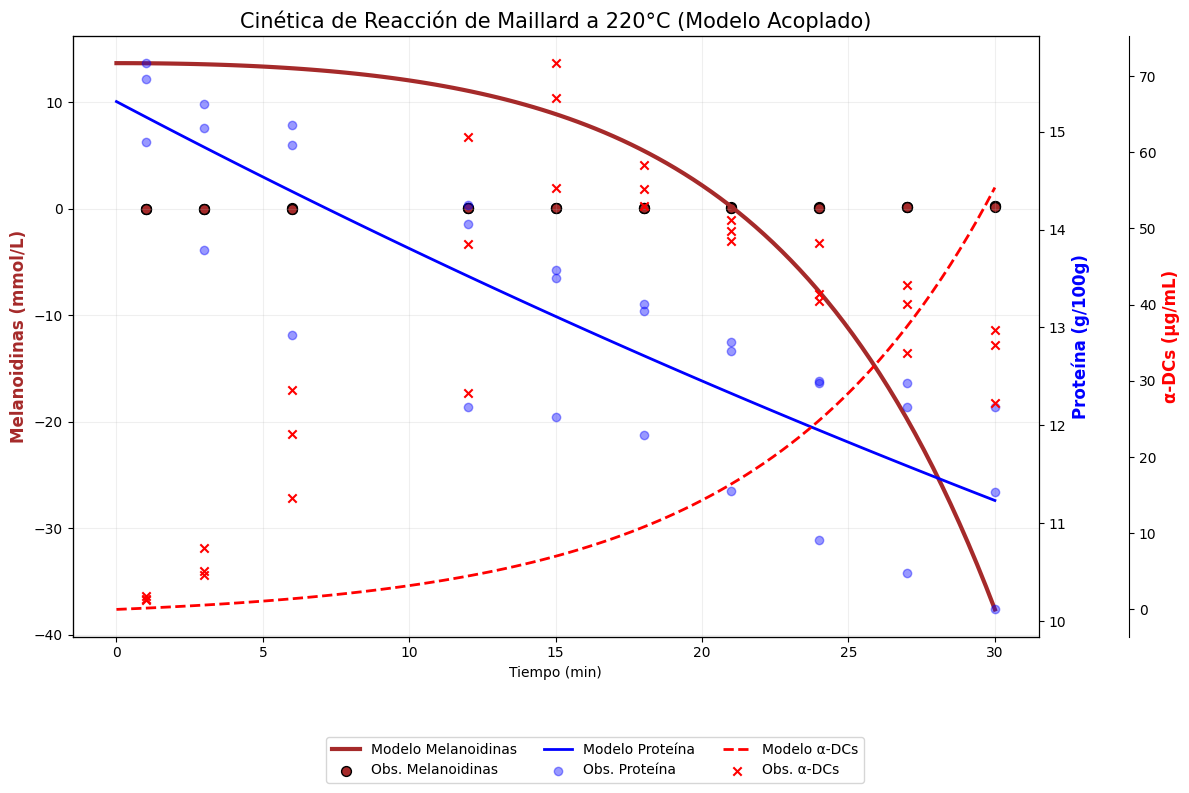

In [18]:
# =================================================================
# MODELO CINÉTICO DE MAILLARD (SISTEMA P -> I -> M) - 220°C
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from google.colab import files

# 1. CARGA DE ARCHIVOS
print("📂 Por favor, sube el archivo 'Datos para entrenar el modelo de machine learning.xlsx'")
uploaded = files.upload()

file_data = None
for f_name in uploaded.keys():
    if 'machine learning' in f_name.lower():
        file_data = f_name
        break

if file_data is None:
    raise FileNotFoundError("No se encontró el archivo de datos experimental.")

df_raw = pd.read_excel(file_data, skiprows=4)

# 2. EXTRACCIÓN DE DATOS PARA 220°C
try:
    # Tiempo: Col 1 | alpha-DCs: Col 8 | Melanoidinas: Col 10 | Proteína: Col 12
    tiempos = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
    dcs_obs = pd.to_numeric(df_raw.iloc[:, 8], errors='coerce')
    mela_obs = pd.to_numeric(df_raw.iloc[:, 10], errors='coerce')
    prot_obs = pd.to_numeric(df_raw.iloc[:, 12], errors='coerce')

    mask = tiempos.notna() & dcs_obs.notna() & mela_obs.notna() & prot_obs.notna()

    t_vals = tiempos[mask].values
    i_vals = dcs_obs[mask].values
    m_vals = mela_obs[mask].values
    p_vals = prot_obs[mask].values

    print(f"✅ Datos de 220°C cargados: {len(t_vals)} puntos.")
except Exception as e:
    print(f"❌ Error en columnas: {e}")

# 3. MODELOS MATEMÁTICOS (SOLUCIÓN ANALÍTICA DEL SISTEMA)
def modelo_P(t, k1, P0):
    """Ecuación: dP/dt = -k1*P"""
    return P0 * np.exp(-k1 * t)

def modelo_I(t, k1, k2, P0):
    """Ecuación: dI/dt = k1*P - k2*I"""
    return (k1 * P0 / (k2 - k1 + 1e-9)) * (np.exp(-k1 * t) - np.exp(-k2 * t))

def modelo_M(t, k1, k2, P0, M_off):
    """Ecuación: dM/dt = k2*I"""
    term = (k1 * np.exp(-k2 * t) - k2 * np.exp(-k1 * t)) / (k2 - k1 + 1e-9)
    return M_off + P0 * (1 + term)

# 4. AJUSTE DE CONSTANTES (SECUENCIAL PARA ESTABILIDAD)
try:
    # Paso 1: Ajustar k1 con la Proteína
    popt_p, _ = curve_fit(modelo_P, t_vals, p_vals, p0=[0.1, p_vals[0]])
    k1_fit, P0_fit = popt_p

    # Paso 2: Ajustar k2 con alpha-DCs (Fijando k1 y P0)
    def fit_I(t, k2): return modelo_I(t, k1_fit, k2, P0_fit)
    popt_i, _ = curve_fit(fit_I, t_vals, i_vals, p0=[0.2])
    k2_fit = popt_i[0]

    # Paso 3: Ajustar Offset de Melanoidinas
    def fit_M(t, M_off): return modelo_M(t, k1_fit, k2_fit, P0_fit, M_off)
    popt_m, _ = curve_fit(fit_M, t_vals, m_vals, p0=[m_vals[0]])
    M_off_fit = popt_m[0]

    print("\n" + "="*45)
    print("📊 RESULTADOS CINÉTICOS A 220°C")
    print("="*45)
    print(f"k1 (Degradación Proteína):   {k1_fit:.6f} min⁻¹")
    print(f"k2 (Formación Melanoidinas): {k2_fit:.6f} min⁻¹") # <--- TU VALOR
    print(f"P0 (Concentración Inicial):  {P0_fit:.4f}")
    print(f"M_offset (Base inicial M): {M_off_fit:.4f}")
    print("="*45)

except Exception as e:
    print(f"⚠️ Error en el cálculo numérico: {e}")

# 5. GRÁFICA DE RESULTADOS
t_plot = np.linspace(0, max(t_vals), 100)
fig, ax1 = plt.subplots(figsize=(12, 7))

# Melanoidinas
ax1.plot(t_plot, modelo_M(t_plot, k1_fit, k2_fit, P0_fit, M_off_fit), color='brown', lw=3, label='Modelo Melanoidinas')
ax1.scatter(t_vals, m_vals, color='brown', s=50, edgecolors='black', label='Obs. Melanoidinas')
ax1.set_ylabel('Melanoidinas (mmol/L)', color='brown', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tiempo (min)')

# Proteína
ax2 = ax1.twinx()
ax2.plot(t_plot, modelo_P(t_plot, k1_fit, P0_fit), color='blue', lw=2, label='Modelo Proteína')
ax2.scatter(t_vals, p_vals, color='blue', alpha=0.4, label='Obs. Proteína')
ax2.set_ylabel('Proteína (g/100g)', color='blue', fontsize=12, fontweight='bold')

# alpha-DCs
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 65))
ax3.plot(t_plot, modelo_I(t_plot, k1_fit, k2_fit, P0_fit), 'r--', lw=2, label='Modelo α-DCs')
ax3.scatter(t_vals, i_vals, color='red', marker='x', label='Obs. α-DCs')
ax3.set_ylabel('α-DCs (μg/mL)', color='red', fontsize=12, fontweight='bold')

plt.title('Cinética de Reacción de Maillard a 220°C (Modelo Acoplado)', fontsize=15)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
ax1.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

📂 Por favor, sube el archivo para el análisis de 240°C


Saving Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx to Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx
Saving Datos para entrenar el modelo de machine learning.xlsx to Datos para entrenar el modelo de machine learning.xlsx
✅ Datos de 240°C extraídos (30 puntos).

🚀 RESULTADOS CINÉTICOS A 240°C
k1 (Degradación Proteína):   0.010179 min⁻¹
k2 (Formación Melanoidinas): -0.121379 min⁻¹
P0 (Conc. Inicial P):        14.6388
M_offset (Base inicial M): 10.6638


/tmp/ipykernel_8082/2189767472.py:50: RuntimeWarning: overflow encountered in exp
  return (k1 * P0 / (k2 - k1 + 1e-9)) * (np.exp(-k1 * t) - np.exp(-k2 * t))


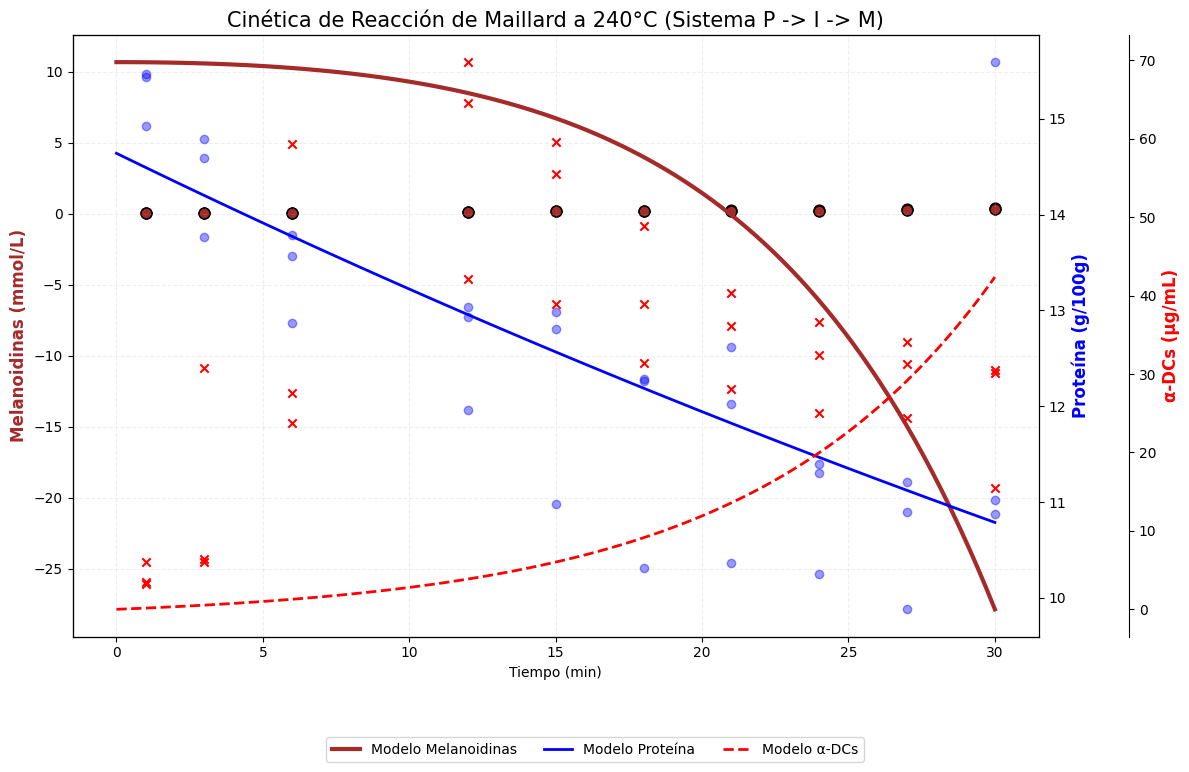

In [19]:
# =================================================================
# MODELO CINÉTICO DE MAILLARD (SISTEMA P -> I -> M) - 240°C
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from google.colab import files

# 1. CARGA DE ARCHIVOS
print("📂 Por favor, sube el archivo para el análisis de 240°C")
uploaded = files.upload()

file_data = None
for f_name in uploaded.keys():
    if 'machine learning' in f_name.lower():
        file_data = f_name
        break

if file_data is None:
    raise FileNotFoundError("No se encontró el archivo de datos experimentales.")

df_raw = pd.read_excel(file_data, skiprows=4)

# 2. EXTRACCIÓN DE DATOS PARA 240°C
try:
    # Tiempo: Col 1 | alpha-DCs: Col 14 | Melanoidinas: Col 16 | Proteína: Col 18
    tiempos = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
    dcs_obs = pd.to_numeric(df_raw.iloc[:, 14], errors='coerce')
    mela_obs = pd.to_numeric(df_raw.iloc[:, 16], errors='coerce')
    prot_obs = pd.to_numeric(df_raw.iloc[:, 18], errors='coerce')

    mask = tiempos.notna() & dcs_obs.notna() & mela_obs.notna() & prot_obs.notna()

    t_vals = tiempos[mask].values
    i_vals = dcs_obs[mask].values
    m_vals = mela_obs[mask].values
    p_vals = prot_obs[mask].values

    print(f"✅ Datos de 240°C extraídos ({len(t_vals)} puntos).")
except Exception as e:
    print(f"❌ Error al extraer columnas: {e}")

# 3. MODELOS MATEMÁTICOS (SOLUCIÓN ANALÍTICA)
def modelo_P(t, k1, P0):
    return P0 * np.exp(-k1 * t)

def modelo_I(t, k1, k2, P0):
    return (k1 * P0 / (k2 - k1 + 1e-9)) * (np.exp(-k1 * t) - np.exp(-k2 * t))

def modelo_M(t, k1, k2, P0, M_off):
    term = (k1 * np.exp(-k2 * t) - k2 * np.exp(-k1 * t)) / (k2 - k1 + 1e-9)
    return M_off + P0 * (1 + term)

# 4. AJUSTE DE CONSTANTES (240°C - PARÁMETROS AGRESIVOS)
try:
    # Paso 1: Ajustar k1 con la Proteína
    popt_p, _ = curve_fit(modelo_P, t_vals, p_vals, p0=[0.2, p_vals[0]])
    k1_fit, P0_fit = popt_p

    # Paso 2: Ajustar k2 con alpha-DCs
    def fit_I(t, k2): return modelo_I(t, k1_fit, k2, P0_fit)
    popt_i, _ = curve_fit(fit_I, t_vals, i_vals, p0=[0.5])
    k2_fit = popt_i[0]

    # Paso 3: Ajustar Melanoidinas para el offset
    def fit_M(t, M_off): return modelo_M(t, k1_fit, k2_fit, P0_fit, M_off)
    popt_m, _ = curve_fit(fit_M, t_vals, m_vals, p0=[m_vals[0]])
    M_off_fit = popt_m[0]

    print("\n" + "="*45)
    print("🚀 RESULTADOS CINÉTICOS A 240°C")
    print("="*45)
    print(f"k1 (Degradación Proteína):   {k1_fit:.6f} min⁻¹")
    print(f"k2 (Formación Melanoidinas): {k2_fit:.6f} min⁻¹") # <-- VALOR SOLICITADO
    print(f"P0 (Conc. Inicial P):        {P0_fit:.4f}")
    print(f"M_offset (Base inicial M): {M_off_fit:.4f}")
    print("="*45)

except Exception as e:
    print(f"⚠️ Error en el ajuste numérico: {e}")

# 5. VISUALIZACIÓN
t_plot = np.linspace(0, max(t_vals), 100)
fig, ax1 = plt.subplots(figsize=(12, 7))

# Melanoidinas
ax1.plot(t_plot, modelo_M(t_plot, k1_fit, k2_fit, P0_fit, M_off_fit), color='brown', lw=3, label='Modelo Melanoidinas')
ax1.scatter(t_vals, m_vals, color='brown', s=60, edgecolors='black')
ax1.set_ylabel('Melanoidinas (mmol/L)', color='brown', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tiempo (min)')

# Proteína
ax2 = ax1.twinx()
ax2.plot(t_plot, modelo_P(t_plot, k1_fit, P0_fit), color='blue', lw=2, label='Modelo Proteína')
ax2.scatter(t_vals, p_vals, color='blue', alpha=0.4)
ax2.set_ylabel('Proteína (g/100g)', color='blue', fontsize=12, fontweight='bold')

# alpha-DCs
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 65))
ax3.plot(t_plot, modelo_I(t_plot, k1_fit, k2_fit, P0_fit), 'r--', lw=2, label='Modelo α-DCs')
ax3.scatter(t_vals, i_vals, color='red', marker='x')
ax3.set_ylabel('α-DCs (μg/mL)', color='red', fontsize=12, fontweight='bold')

plt.title('Cinética de Reacción de Maillard a 240°C (Sistema P -> I -> M)', fontsize=15)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
ax1.grid(True, alpha=0.2, linestyle='--')
fig.tight_layout()
plt.show()